In [1]:
from networkx import is_d_separator
from pgmpy.base import DAG

In [2]:
# Reminder that we construct DAGs by defining edges.
# DAG is a base calss for BayesianNetwork class, so objects here will work on 
# DAG related objects and BayesianNetwork objects! 

dag = DAG([  # life goal: get the right projects and build these so frequently that looking at these pairs forms the image of the DAG in my mind
    ('I', 'U'),
    ('I', 'M'),
    ('M', 'U'),
    ('J', 'V'),
    ('J', 'M'),
    ('M', 'V')
])

print(is_d_separator(dag, {"U"}, {"V"}, {"M"}))

False


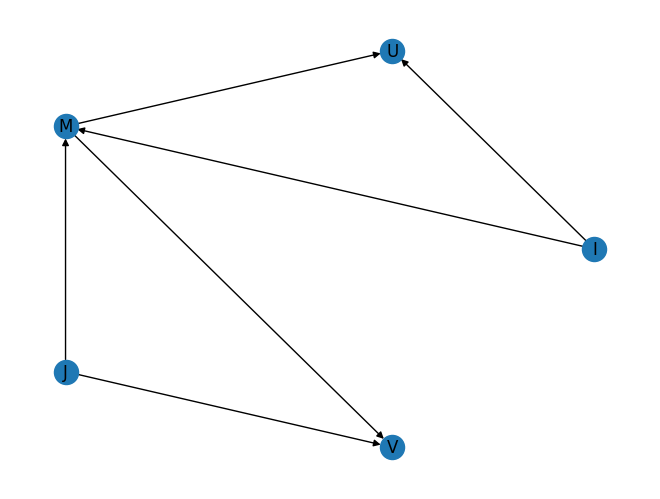

In [3]:
import networkx as nx

nx.draw_circular(
    dag,
    with_labels=True
)

In [4]:
print(is_d_separator(dag, {"U"}, {"V"}, {"M", "I", "J"}))

True


In [5]:
print(is_d_separator(dag, {"U"}, {"V"}, {"M", "I"}))

True


In [6]:
print(is_d_separator(dag, {"U"}, {"V"}, {"M", "J"}))

True


## Refuting DAG

In [7]:
import polars as pl
survey_url = "https://raw.githubusercontent.com/altdeep/causalML/refs/heads/master/datasets/transportation_survey.csv"
full_data = pl.read_csv(survey_url)

In [8]:
data = full_data[:30]
data

A,S,E,O,R,T
str,str,str,str,str,str
"""adult""","""F""","""high""","""emp""","""small""","""train"""
"""young""","""M""","""high""","""emp""","""big""","""car"""
"""adult""","""M""","""uni""","""emp""","""big""","""other"""
"""old""","""F""","""uni""","""emp""","""big""","""car"""
"""young""","""F""","""uni""","""emp""","""big""","""car"""
…,…,…,…,…,…
"""adult""","""F""","""high""","""emp""","""big""","""car"""
"""young""","""M""","""high""","""emp""","""big""","""car"""
"""young""","""M""","""uni""","""emp""","""big""","""car"""


In [9]:
from pgmpy.estimators.CITests import chi_square
significance = .05

result = chi_square(
    X="E", Y="T", Z={"O", "R"},
    data=data.to_pandas(),
    boolean=False,
    significance_level=significance
)

result

/Users/hemphillmc/learning/causal_ai/.venv/lib/python3.12/site-packages/pgmpy/utils/utils.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


(1.1611111111111112, 0.5595873983053805, 2)

In [10]:
from pgmpy.estimators.CITests import chi_square
significance = .05

result = chi_square(
    X="E", Y="T", Z={"O", "R"},
    data=data.to_pandas(),
    boolean=True,
    significance_level=significance
)

result

True

In [11]:
from pprint import pprint
from pgmpy.base import DAG
from pgmpy.independencies import IndependenceAssertion

dag = DAG([
    ("A", "E"),
    ("S", "E"),
    ("E", "O"),
    ("E", "R"),
    ("O", "T"),
    ("R", "T")
])

dseps = dag.get_independencies(include_latents=False)
pprint(dseps)

(E ⟂ T | R, O)
(E ⟂ T | S, R, O)
(E ⟂ T | R, A, O)
(E ⟂ T | S, R, A, O)
(R ⟂ S, A, O | E)
(R ⟂ S, A | E, O)
(R ⟂ A, O | S, E)
(R ⟂ S, O | E, A)
(R ⟂ S, A | E, T)
(R ⟂ A | S, E, O)
(R ⟂ S | E, A, O)
(R ⟂ S, A | E, T, O)
(R ⟂ O | S, E, A)
(R ⟂ A | S, E, T)
(R ⟂ S | E, A, T)
(R ⟂ A | S, E, T, O)
(R ⟂ S | E, T, A, O)
(O ⟂ S, R, A | E)
(O ⟂ S, A | E, R)
(O ⟂ R, A | S, E)
(O ⟂ S, R | E, A)
(O ⟂ S, A | E, T)
(O ⟂ A | S, E, R)
(O ⟂ S | E, R, A)
(O ⟂ S, A | E, R, T)
(O ⟂ R | S, E, A)
(O ⟂ A | S, E, T)
(O ⟂ S | E, A, T)
(O ⟂ A | S, E, R, T)
(O ⟂ S | E, R, A, T)
(S ⟂ A)
(S ⟂ O, R, T | E)
(S ⟂ O, T | E, R)
(S ⟂ R, T | E, O)
(S ⟂ O, R, T | E, A)
(S ⟂ R, O | E, T)
(S ⟂ T | R, O)
(S ⟂ T | E, R, O)
(S ⟂ O, T | E, R, A)
(S ⟂ O | E, R, T)
(S ⟂ R, T | E, A, O)
(S ⟂ R | E, T, O)
(S ⟂ R, O | E, A, T)
(S ⟂ T | R, A, O)
(S ⟂ T | E, R, A, O)
(S ⟂ O | E, R, A, T)
(S ⟂ R | E, T, A, O)
(A ⟂ S)
(A ⟂ O, R, T | E)
(A ⟂ O, T | E, R)
(A ⟂ R, T | E, O)
(A ⟂ O, R, T | S, E)
(A ⟂ R, O | E, T)
(A ⟂ T | R, O)
(A ⟂ T | E, 

In [12]:
type(dseps.get_assertions())

list

In [13]:
data

A,S,E,O,R,T
str,str,str,str,str,str
"""adult""","""F""","""high""","""emp""","""small""","""train"""
"""young""","""M""","""high""","""emp""","""big""","""car"""
"""adult""","""M""","""uni""","""emp""","""big""","""other"""
"""old""","""F""","""uni""","""emp""","""big""","""car"""
"""young""","""F""","""uni""","""emp""","""big""","""car"""
…,…,…,…,…,…
"""adult""","""F""","""high""","""emp""","""big""","""car"""
"""young""","""M""","""high""","""emp""","""big""","""car"""
"""young""","""M""","""uni""","""emp""","""big""","""car"""


In [14]:
def test_dsep(dsep):
    test_outputs = []
    for X in list(dsep.get_assertion()[0]):
        for Y in list(dsep.get_assertion()[1]):
            Z = list(dsep.get_assertion()[2])
            test_result = chi_square(
                X=X, Y=Y, Z=Z,
                data=data.to_pandas(),
                boolean=True,
                significance_level=significance
            )

            assertion = IndependenceAssertion(X, Y, Z)
            test_outputs.append((assertion, test_result))

    return test_outputs

In [15]:
results = [test_dsep(dsep) for dsep in dseps.get_assertions()]
results = dict([item for sublist in results for item in sublist])
pprint(results)

{(R ⟂ S | E, A, T): True,
 (R ⟂ A | S, E, T): True,
 (R ⟂ A | S, E, O): True,
 (R ⟂ S | E, A): True,
 (A ⟂ T | S, E, R): True,
 (E ⟂ T | S, R, A, O): True,
 (O ⟂ A | E, R, T): True,
 (S ⟂ T | E, R, A): True,
 (S ⟂ T | E): True,
 (A ⟂ T | S, E, R, O): True,
 (O ⟂ S | E, A, T): True,
 (R ⟂ A | E, O): True,
 (O ⟂ S | E, R, A): True,
 (S ⟂ T | E, O): True,
 (A ⟂ T | S, R, O): True,
 (O ⟂ A | S, E, R, T): True,
 (E ⟂ T | R, O): True,
 (R ⟂ A | E): True,
 (O ⟂ S | E, R, A, T): True,
 (O ⟂ S | E, A): True,
 (R ⟂ S | E, A, O): True,
 (R ⟂ O | S, E): False,
 (O ⟂ A | E, R): True,
 (A ⟂ T | R, O): True,
 (O ⟂ S | E, T): True,
 (R ⟂ S | O, E, A, T): True,
 (A ⟂ T | E, R): True,
 (R ⟂ A | E, T): True,
 (S ⟂ T | E, R, A, O): True,
 (R ⟂ S | E): True,
 (O ⟂ A | E): True,
 (S ⟂ T | R, O): True,
 (E ⟂ T | S, R, O): True,
 (O ⟂ S | E, R, T): True,
 (R ⟂ O | E, A): False,
 (R ⟂ S | E, O, T): True,
 (R ⟂ O | S, E, A): False,
 (R ⟂ A | E, O, T): True,
 (S ⟂ T | E, R): True,
 (R ⟂ A | S, E): True,
 (E ⟂ T 

In [16]:
num_pass = sum(results.values())
num_dseps = len(dseps.independencies)
num_fail = num_dseps - num_pass
print(num_fail/num_dseps)

0.2875


### Refuting a Causal DAG Given Latent Variables

I really love this section because it's a reminder to focus on solving a problem, not just admiring data. Thinking in this way protects us from rabbit holes while attempting to reason through incomplete datasets. 

Verma constraints or functional constraints - same concept, constraints introduced by having a dataset that doesn't reflect all the variables in the DGP

Author introduces how to reason around these by finding tests that don't depend directly on the latent variable

#### 4.5.3 Testing a Functional Constraint

We'll run tests on functional constraints in a model presented in the book using a naive bayes classifier

In [17]:
# 4.5.3 Testing a Functional Constraint

from functools import partial
import numpy as np
import pandas as pd

data_url = "https://raw.githubusercontent.com/altdeep/causalML/master/datasets/cigs_and_cancer.csv"
data = pl.read_csv(data_url)

In [18]:
data

C,S,T,L
f64,str,str,bool
9.57,"""Med""","""Low""",true
8.8,"""High""","""High""",false
8.33,"""High""","""High""",true
7.72,"""High""","""High""",true
8.0,"""High""","""High""",true
…,…,…,…
4.87,"""High""","""High""",true
9.42,"""High""","""High""",false
7.27,"""Low""","""Low""",false


In [19]:
# This is the more polars-friendly way to discretize the "C" column

cost_lower = np.quantile(data["C"], 1/3)
cost_upper = np.quantile(data["C"], 2/3)

data_disc = (
    data
    .select(
        pl.col("C").cut(
            breaks=[cost_lower, cost_upper],
            labels=["Low", "Med", "High"],
            left_closed=True  # includes the "break" value in the "Med" and "High" bins. 
        ).cast(str),
        "S", 
        "T", 
        "L"
    )
)

data_disc

C,S,T,L
str,str,str,bool
"""High""","""Med""","""Low""",true
"""Med""","""High""","""High""",false
"""Med""","""High""","""High""",true
"""Med""","""High""","""High""",true
"""Med""","""High""","""High""",true
…,…,…,…
"""Low""","""High""","""High""",true
"""High""","""High""","""High""",false
"""Low""","""Low""","""Low""",false


In [32]:
# Now that our data are prepared for the classifier, let's fit the model

from pgmpy.inference import VariableElimination
from pgmpy.models import NaiveBayes

model_L_given_CST = NaiveBayes()  # probability of lung cancer given cost, smoking status, and tar in lungs
model_L_given_CST.fit(data_disc.to_pandas(), 'L')
infer_L_given_CST = VariableElimination(model_L_given_CST)


In [33]:
def p_L_given_CST(L_val, C_val, S_val, T_val):
    result_out = infer_L_given_CST.query(
        variables=["L"],
        evidence={"C": C_val, "S": S_val, "T": T_val},
        show_progress=False
    )

    var_outcomes = result_out.state_names["L"]
    var_values = result_out.values
    prob = dict(zip(var_outcomes, var_values))
    return prob[L_val]

In [34]:
model_S_given_C = NaiveBayes()
model_S_given_C.fit(data_disc.to_pandas(), 'S')
infer_S_given_C = VariableElimination(model_S_given_C)

In [35]:
def p_S_given_C(S_val, C_val):
    result_out = infer_S_given_C.query(
        variables=["S"],
        evidence={"C": C_val},
        show_progress=False
    )

    var_names = result_out.state_names["S"]
    var_values = result_out.values
    prob = dict(zip(var_names, var_values))
    return prob[S_val]

In [36]:
def h_function(L, C, T):
    summ = 0
    for s in ["Low", "Med", "High"]:
        summ += p_L_given_CST(L, C, s, T) * p_S_given_C(s, C)
    
    return summ

In [37]:
# Enumerates each possible value of Cost, Tar, and Lung Cancer
ctl_outcomes = pl.DataFrame(
    [
        (C, T, L)
        for C in ["Low", "Med", "High"]
        for T in ["Low", "High"]
        for L in [False, True]
    ],
    schema = ["C", "T", "L"]
)

ctl_outcomes

/var/folders/t1/21wrhhsd495b4qhps3_8vdw40000gn/T/ipykernel_1804/1784172615.py:2: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  ctl_outcomes = pl.DataFrame(


C,T,L
str,str,bool
"""Low""","""Low""",false
"""Low""","""Low""",true
"""Low""","""High""",false
"""Low""","""High""",true
"""Med""","""Low""",false
…,…,…
"""Med""","""High""",true
"""High""","""Low""",false
"""High""","""Low""",true


In [54]:
# for each value, we'll apply h(L, C, T)

h_dist = (
    ctl_outcomes
    .with_columns(
        pl.Series(ctl_outcomes.map_rows(lambda row: h_function(row[2], row[0], row[1]))['map'].to_list()).alias("h_func")
    )
)

h_dist

C,T,L,h_func
str,str,bool,f64
"""Low""","""Low""",false,0.392395
"""Low""","""Low""",true,0.607605
"""Low""","""High""",false,0.255435
"""Low""","""High""",true,0.744565
"""Med""","""Low""",false,0.522868
…,…,…,…
"""Med""","""High""",true,0.630233
"""High""","""Low""",false,0.495525
"""High""","""Low""",true,0.504475


In [57]:
# merge to get h(L, C, T) for each row of data
df_mod = (
    data_disc
    .join(
        h_dist,
        on=["C", "T", "L"],
        how="left"
    )
)

df_mod

C,S,T,L,h_func
str,str,str,bool,f64
"""High""","""Med""","""Low""",true,0.504475
"""Med""","""High""","""High""",false,0.369767
"""Med""","""High""","""High""",true,0.630233
"""Med""","""High""","""High""",true,0.630233
"""Med""","""High""","""High""",true,0.630233
…,…,…,…,…
"""Low""","""High""","""High""",true,0.744565
"""High""","""High""","""High""",false,0.344616
"""Low""","""Low""","""Low""",false,0.392395


In [61]:
import plotly.express as px
fig = px.box(
    df_mod,
    x="C",
    y="h_func"
)

fig.show()

In [62]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

In [74]:
model = ols('h_func ~C', data=df_mod.to_pandas()).fit()
aov_table = sm.stats.anova_lm(model, typ=2)
print(aov_table["PR(>F)"]["C"])

model = ols('h_func ~ T', data=df_mod.to_pandas()).fit()
aov_table = sm.stats.anova_lm(model, typ=2)
print(aov_table["PR(>F)"]["T"])

model = ols('h_func ~ L', data=df_mod.to_pandas()).fit()
aov_table = sm.stats.anova_lm(model, typ=2)
print(aov_table["PR(>F)"]["L"])

0.1876482733083194
0.07635987808881305
4.700953975260171e-28
